# Test Smart Search Model

In [1]:
%pip install transformers torch torchvision pillow numpy matplotlib sentencepiece sacremoses

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
from transformers import CLIPModel, CLIPProcessor, MarianMTModel, MarianTokenizer

device = "cuda" if torch.cuda.is_available() else "cpu"
device

c:\Users\erikf\repositories\Moon_NFT_Exchange\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'cpu'

## Load CLIP

In [3]:
clip_model_id = "openai/clip-vit-large-patch14"

clip_model = CLIPModel.from_pretrained(clip_model_id).to(device)
clip_processor = CLIPProcessor.from_pretrained(clip_model_id)
clip_model.eval()

clip_model_id

Loading weights: 100%|██████████| 590/590 [00:00<00:00, 5379.88it/s]
CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


'openai/clip-vit-large-patch14'

## Load RU -> EN Translator

In [4]:
translator_model_id = "Helsinki-NLP/opus-mt-ru-en"

translator_tokenizer = MarianTokenizer.from_pretrained(translator_model_id)
translator_model = MarianMTModel.from_pretrained(translator_model_id).to(device)
translator_model.eval()

translator_model_id

c:\Users\erikf\repositories\Moon_NFT_Exchange\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\erikf\.cache\huggingface\hub\models--Helsinki-NLP--opus-mt-ru-en. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 258/258 [00:00<00:00, 27263.87it/s]


'Helsinki-NLP/opus-mt-ru-en'

## Load Present Images

In [5]:
image_dir = Path("images/presents")
if not image_dir.exists():
    image_dir = Path("../images/presents")

image_extensions = {".png", ".jpg", ".jpeg", ".webp", ".gif"}
paths = sorted(
    path
    for path in image_dir.iterdir()
    if path.is_file() and path.suffix.lower() in image_extensions
)

images = []
valid_paths = []

for path in paths:
    try:
        images.append(Image.open(path).convert("RGB"))
        valid_paths.append(path)
    except Exception as exc:
        print("Skip:", path.name, exc)

len(images), [path.name for path in valid_paths]

(44,
 ['cap.png',
  'card.png',
  'generated_04c7158c7e1b4dceb94721ecc45170ab.png',
  'generated_05c1e9c895854c1e87550fdbfa360680.png',
  'generated_09f68eeeb8cd44d982810981c6e6fcfa.png',
  'generated_0dab5a6d48984e509dc2533dd41a62e3.png',
  'generated_254c65eef9324397970c4924cae2e8ca.png',
  'generated_26323046076d459ea9e67fb41529845e.png',
  'generated_36a9a93c5ef24ac481dc31bcd6b29be6.png',
  'generated_3fbb32fdeaa3404eb9244a97a4312ef9.png',
  'generated_496f8f2b3be24025b8f4b048f319ba98.png',
  'generated_4c0541c5ebec44b290fce02a4ab9556a.png',
  'generated_530b19fe2dae4d5daacdd925febfcc24.png',
  'generated_53fad82741c54e18b6bf81b7a2dee4bd.png',
  'generated_5506c159875e4566935f901aafb5b0bd.png',
  'generated_5c5969242dbd45aca3f184c101921983.png',
  'generated_5fc083af68a84c34b93342d0c7d40e1d.png',
  'generated_7a98614cf079454ab5c33e64baa4afdb.png',
  'generated_92fa0573fbfe4ad8b2e20b6693955b51.png',
  'generated_9406aee931f548ae8ec1183a3e193487.png',
  'generated_9b1d2cf6b6ef4084a0f

## Build Image Embeddings

In [6]:
def get_pooler_output(model_output):
    if hasattr(model_output, "pooler_output"):
        return model_output.pooler_output
    return model_output


with torch.no_grad():
    image_inputs = clip_processor(
        images=images,
        return_tensors="pt"
    ).to(device)

    image_outputs = clip_model.get_image_features(**image_inputs)
    image_features = get_pooler_output(image_outputs)
    image_features = F.normalize(image_features, p=2, dim=-1)

image_embeddings = image_features.cpu().numpy()
image_embeddings.shape

(44, 768)

## Search Helpers

In [7]:
def has_cyrillic(text: str) -> bool:
    return any("а" <= ch.lower() <= "я" or ch.lower() == "ё" for ch in text)


def translate_ru_to_en(text: str) -> str:
    inputs = translator_tokenizer(
        [text],
        return_tensors="pt",
        padding=True,
        truncation=True
    ).to(device)

    with torch.no_grad():
        generated = translator_model.generate(**inputs)

    return translator_tokenizer.decode(generated[0], skip_special_tokens=True)


def prepare_query_for_clip(query: str) -> str:
    query = query.strip()
    if has_cyrillic(query):
        return translate_ru_to_en(query)
    return query


def encode_text_clip(texts):
    with torch.no_grad():
        text_inputs = clip_processor(
            text=texts,
            return_tensors="pt",
            padding=True,
            truncation=True
        ).to(device)

        text_outputs = clip_model.get_text_features(**text_inputs)
        text_features = get_pooler_output(text_outputs)
        text_features = F.normalize(text_features, p=2, dim=-1)

    return text_features.cpu().numpy()


def search_clip(query: str, top_k: int = 5):
    query_for_clip = prepare_query_for_clip(query)
    text_embedding = encode_text_clip([query_for_clip])[0]

    scores = image_embeddings @ text_embedding
    best_indices = np.argsort(scores)[::-1][:top_k]

    return [
        {
            "name": valid_paths[i].name,
            "path": str(valid_paths[i]),
            "score": float(scores[i]),
            "query_for_clip": query_for_clip,
        }
        for i in best_indices
    ]

In [8]:
def show_search(query: str, top_k: int = 5):
    results = search_clip(query, top_k)
    query_for_clip = results[0]["query_for_clip"] if results else prepare_query_for_clip(query)

    plt.figure(figsize=(15, 4))

    for idx, item in enumerate(results):
        img = Image.open(item["path"]).convert("RGB")

        plt.subplot(1, top_k, idx + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f'{item["name"]}\n{item["score"]:.3f}')

    plt.suptitle(f'{query} -> {query_for_clip}')
    plt.show()

    return results

## Test Queries

In [9]:
translate_ru_to_en("синяя лягушка с сердцем")

'blue frog with heart'

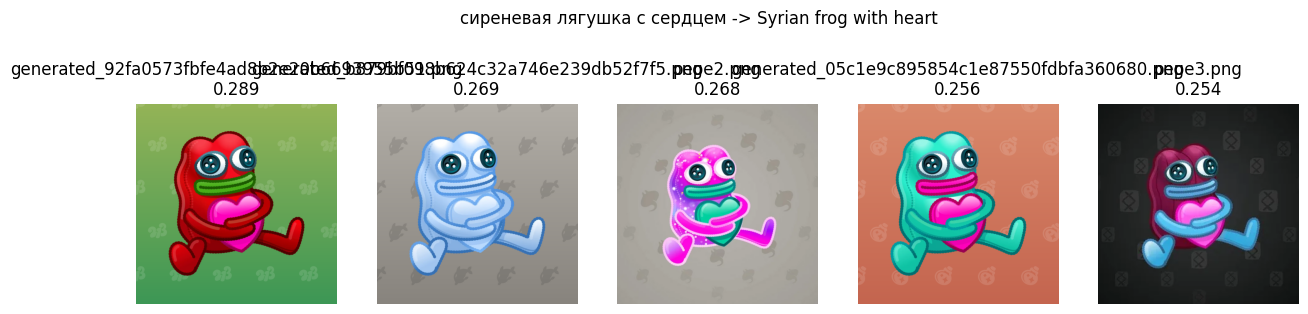

[{'name': 'generated_92fa0573fbfe4ad8b2e20b6693955b51.png',
  'path': '..\\images\\presents\\generated_92fa0573fbfe4ad8b2e20b6693955b51.png',
  'score': 0.28868991136550903,
  'query_for_clip': 'Syrian frog with heart'},
 {'name': 'generated_b879bf098b624c32a746e239db52f7f5.png',
  'path': '..\\images\\presents\\generated_b879bf098b624c32a746e239db52f7f5.png',
  'score': 0.26860690116882324,
  'query_for_clip': 'Syrian frog with heart'},
 {'name': 'pepe2.png',
  'path': '..\\images\\presents\\pepe2.png',
  'score': 0.2677306532859802,
  'query_for_clip': 'Syrian frog with heart'},
 {'name': 'generated_05c1e9c895854c1e87550fdbfa360680.png',
  'path': '..\\images\\presents\\generated_05c1e9c895854c1e87550fdbfa360680.png',
  'score': 0.25629180669784546,
  'query_for_clip': 'Syrian frog with heart'},
 {'name': 'pepe3.png',
  'path': '..\\images\\presents\\pepe3.png',
  'score': 0.25378262996673584,
  'query_for_clip': 'Syrian frog with heart'}]

In [16]:
show_search("сиреневая лягушка с сердцем", top_k=5)

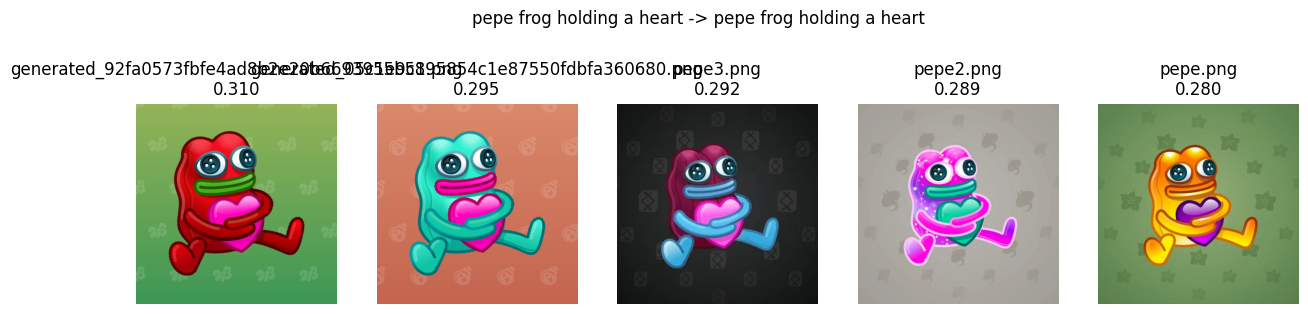

[{'name': 'generated_92fa0573fbfe4ad8b2e20b6693955b51.png',
  'path': '..\\images\\presents\\generated_92fa0573fbfe4ad8b2e20b6693955b51.png',
  'score': 0.3104497790336609,
  'query_for_clip': 'pepe frog holding a heart'},
 {'name': 'generated_05c1e9c895854c1e87550fdbfa360680.png',
  'path': '..\\images\\presents\\generated_05c1e9c895854c1e87550fdbfa360680.png',
  'score': 0.2945740222930908,
  'query_for_clip': 'pepe frog holding a heart'},
 {'name': 'pepe3.png',
  'path': '..\\images\\presents\\pepe3.png',
  'score': 0.2922687828540802,
  'query_for_clip': 'pepe frog holding a heart'},
 {'name': 'pepe2.png',
  'path': '..\\images\\presents\\pepe2.png',
  'score': 0.28941938281059265,
  'query_for_clip': 'pepe frog holding a heart'},
 {'name': 'pepe.png',
  'path': '..\\images\\presents\\pepe.png',
  'score': 0.2798604965209961,
  'query_for_clip': 'pepe frog holding a heart'}]

In [11]:
show_search("pepe frog holding a heart", top_k=5)

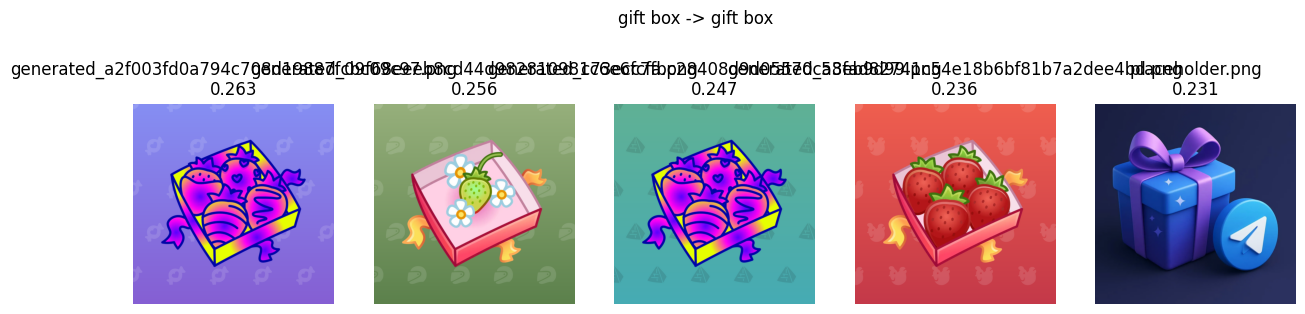

[{'name': 'generated_a2f003fd0a794c708d19887fcbc09c97.png',
  'path': '..\\images\\presents\\generated_a2f003fd0a794c708d19887fcbc09c97.png',
  'score': 0.2632722854614258,
  'query_for_clip': 'gift box'},
 {'name': 'generated_09f68eeeb8cd44d982810981c6e6fcfa.png',
  'path': '..\\images\\presents\\generated_09f68eeeb8cd44d982810981c6e6fcfa.png',
  'score': 0.25622010231018066,
  'query_for_clip': 'gift box'},
 {'name': 'generated_c73ecc7fbc28408d9d05570ca8eb9d99.png',
  'path': '..\\images\\presents\\generated_c73ecc7fbc28408d9d05570ca8eb9d99.png',
  'score': 0.24694259464740753,
  'query_for_clip': 'gift box'},
 {'name': 'generated_53fad82741c54e18b6bf81b7a2dee4bd.png',
  'path': '..\\images\\presents\\generated_53fad82741c54e18b6bf81b7a2dee4bd.png',
  'score': 0.23551304638385773,
  'query_for_clip': 'gift box'},
 {'name': 'placeholder.png',
  'path': '..\\images\\presents\\placeholder.png',
  'score': 0.23114967346191406,
  'query_for_clip': 'gift box'}]

In [12]:
show_search("gift box", top_k=5)